<a href="https://colab.research.google.com/github/Umukundwa004/Machine_learning-assignments/blob/main/formative1_vestine_UMUKUNDWA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .

Make sure to display outputs for each code cell when submitting.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

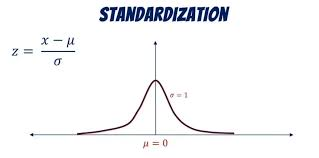


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv("price_of_healthy_diet_clean.csv")
print(data.head(10))
print(data.dtypes)

   country_code  country  region  year  cost_healthy_diet_ppp_usd  \
0             8  Albania  Africa  2017                       3.04   
1             8  Albania  Africa  2018                       3.13   
2             8  Albania  Africa  2019                       3.32   
3             8  Albania  Africa  2020                       3.40   
4             8  Albania  Africa  2021                       3.49   
5             8  Albania  Africa  2022                       4.14   
6             8  Albania  Africa  2023                       4.58   
7             8  Albania  Africa  2024                       4.77   
8            12  Algeria  Africa  2017                       4.10   
9            12  Algeria  Africa  2018                       4.16   

   annual_cost_healthy_diet_usd  cost_vegetables_ppp_usd  cost_fruits_ppp_usd  \
0                       1109.60                      NaN                  NaN   
1                       1142.45                      NaN                  NaN 

### Upload the Dataset
Please upload the `price_of_healthy_diet_clean.csv` file. Once uploaded, you can re-run the data loading cell (`UwQ6WgkMpfvg`).

In [11]:
numerical_cols = data.select_dtypes(include=np.number).columns
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].mean())

# Ensure X only contains numerical data for standardization
X = data[numerical_cols].values

mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
standardized_data = (X - mean) / std
standardized_data[:5]

array([[-1.66427147e+00, -1.52232061e+00, -7.08735032e-01,
        -7.08735032e-01,  1.09187776e-15, -1.07040872e-15,
         1.29379774e-15],
       [-1.66427147e+00, -1.08615187e+00, -6.08664377e-01,
        -6.08664377e-01,  1.09187776e-15, -1.07040872e-15,
         1.29379774e-15],
       [-1.66427147e+00, -6.49983140e-01, -3.97404106e-01,
        -3.97404106e-01,  1.09187776e-15, -1.07040872e-15,
         1.29379774e-15],
       [-1.66427147e+00, -2.13814405e-01, -3.08452413e-01,
        -3.08452413e-01,  1.09187776e-15, -1.07040872e-15,
         1.29379774e-15],
       [-1.66427147e+00,  2.22354330e-01, -2.08381758e-01,
        -2.08381758e-01, -1.60022219e+00,  9.12446698e-01,
        -3.96640009e-01]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)  # Calculate covariance matrix
cov_matrix

array([[ 1.00072569e+00,  8.14349531e-04, -9.55905390e-02,
        -9.55905390e-02, -4.83950914e-02, -2.83348628e-02,
        -4.57964807e-02],
       [ 8.14349531e-04,  1.00072569e+00,  5.19707393e-01,
         5.19707393e-01,  1.09572084e-17,  5.15633335e-18,
        -2.41703126e-17],
       [-9.55905390e-02,  5.19707393e-01,  1.00072569e+00,
         1.00072569e+00,  1.70429439e-01,  1.45319215e-01,
         1.88796711e-01],
       [-9.55905390e-02,  5.19707393e-01,  1.00072569e+00,
         1.00072569e+00,  1.70429439e-01,  1.45319215e-01,
         1.88796711e-01],
       [-4.83950914e-02,  1.09572084e-17,  1.70429439e-01,
         1.70429439e-01,  1.00072569e+00,  3.96525848e-01,
         8.32533917e-01],
       [-2.83348628e-02,  5.15633335e-18,  1.45319215e-01,
         1.45319215e-01,  3.96525848e-01,  1.00072569e+00,
         8.39713615e-01],
       [-4.57964807e-02, -2.41703126e-17,  1.88796711e-01,
         1.88796711e-01,  8.32533917e-01,  8.39713615e-01,
         1.0007256

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [12]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues, eigenvectors

(array([2.77926336e+00+0.00000000e+00j, 2.04236750e+00+0.00000000e+00j,
        9.97973281e-01+0.00000000e+00j, 5.77727549e-01+0.00000000e+00j,
        6.07748133e-01+0.00000000e+00j, 1.45901783e-16+4.13171372e-17j,
        1.45901783e-16-4.13171372e-17j]),
 array([[ 7.73530363e-02+0.00000000e+00j,  2.92396361e-02+0.00000000e+00j,
         -9.85735321e-01+0.00000000e+00j,  1.17419505e-01+0.00000000e+00j,
          8.77501443e-02+0.00000000e+00j, -1.72951553e-17+1.19990532e-17j,
         -1.72951553e-17-1.19990532e-17j],
        [-2.66158986e-01+0.00000000e+00j, -4.16065780e-01+0.00000000e+00j,
         -1.56473038e-01+0.00000000e+00j, -7.90427063e-01+0.00000000e+00j,
         -3.26787250e-01+0.00000000e+00j, -1.63857182e-16+4.94094388e-17j,
         -1.63857182e-16-4.94094388e-17j],
        [-4.55483974e-01+0.00000000e+00j, -4.16980141e-01+0.00000000e+00j,
          1.18663960e-03+0.00000000e+00j,  3.21578605e-01+0.00000000e+00j,
          1.23481595e-01+0.00000000e+00j, -3.74467823e-0

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [13]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

sorted_eigenvalues = eigenvalues[sorted_indices]


variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
variance_percentage = variance_ratio * 100
cumulative_variance_ratio = np.cumsum(variance_ratio)
cumulative_variance_percentage = cumulative_variance_ratio * 100

print("proportion of variance explained by the first few principal components, along with cumulative variance:")
for i, var in enumerate(variance_ratio[:5]):
    print(f"PC{i+1}: {var:.4f} ({cumulative_variance_ratio[i]:.4f}  cumulative)")

sorted_eigenvectors

proportion of variance explained by the first few principal components, along with cumulative variance:
PC1: 0.3967+0.0000j (0.3967+0.0000j  cumulative)
PC2: 0.2916+0.0000j (0.6883+0.0000j  cumulative)
PC3: 0.1425+0.0000j (0.8308+0.0000j  cumulative)
PC4: 0.0868+0.0000j (0.9175+0.0000j  cumulative)
PC5: 0.0825+0.0000j (1.0000+0.0000j  cumulative)


array([[ 7.73530363e-02+0.00000000e+00j,  2.92396361e-02+0.00000000e+00j,
        -9.85735321e-01+0.00000000e+00j,  8.77501443e-02+0.00000000e+00j,
         1.17419505e-01+0.00000000e+00j, -1.72951553e-17+1.19990532e-17j,
        -1.72951553e-17-1.19990532e-17j],
       [-2.66158986e-01+0.00000000e+00j, -4.16065780e-01+0.00000000e+00j,
        -1.56473038e-01+0.00000000e+00j, -3.26787250e-01+0.00000000e+00j,
        -7.90427063e-01+0.00000000e+00j, -1.63857182e-16+4.94094388e-17j,
        -1.63857182e-16-4.94094388e-17j],
       [-4.55483974e-01+0.00000000e+00j, -4.16980141e-01+0.00000000e+00j,
         1.18663960e-03+0.00000000e+00j,  1.23481595e-01+0.00000000e+00j,
         3.21578605e-01+0.00000000e+00j, -3.74467823e-01+2.85385714e-01j,
        -3.74467823e-01-2.85385714e-01j],
       [-4.55483974e-01+0.00000000e+00j, -4.16980141e-01+0.00000000e+00j,
         1.18663960e-03+0.00000000e+00j,  1.23481595e-01+0.00000000e+00j,
         3.21578605e-01+0.00000000e+00j,  3.74467823e-01-2.8

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [14]:
# Step 6: Project Data onto Principal Components
num_components = 3
reduced_data = np.dot(standardized_data, sorted_eigenvectors[:, :num_components])
reduced_data[:5]

array([[ 0.92207776+0.j,  1.17577969+0.j,  1.87705128+0.j],
       [ 0.71482637+0.j,  0.91084985+0.j,  1.80904013+0.j],
       [ 0.4062848 +0.j,  0.55319229+0.j,  1.74129286+0.j],
       [ 0.20916244+0.j,  0.29753523+0.j,  1.67325532+0.j],
       [ 0.46141705+0.j, -0.37966342+0.j,  1.57283844+0.j]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [15]:
# Step 7: Output the Reduced Data
print(f'Reducing the Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first 5 rows of reduced data

Reducing the Data Shape: (1379, 3)


array([[ 0.92207776+0.j,  1.17577969+0.j,  1.87705128+0.j],
       [ 0.71482637+0.j,  0.91084985+0.j,  1.80904013+0.j],
       [ 0.4062848 +0.j,  0.55319229+0.j,  1.74129286+0.j],
       [ 0.20916244+0.j,  0.29753523+0.j,  1.67325532+0.j],
       [ 0.46141705+0.j, -0.37966342+0.j,  1.57283844+0.j]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

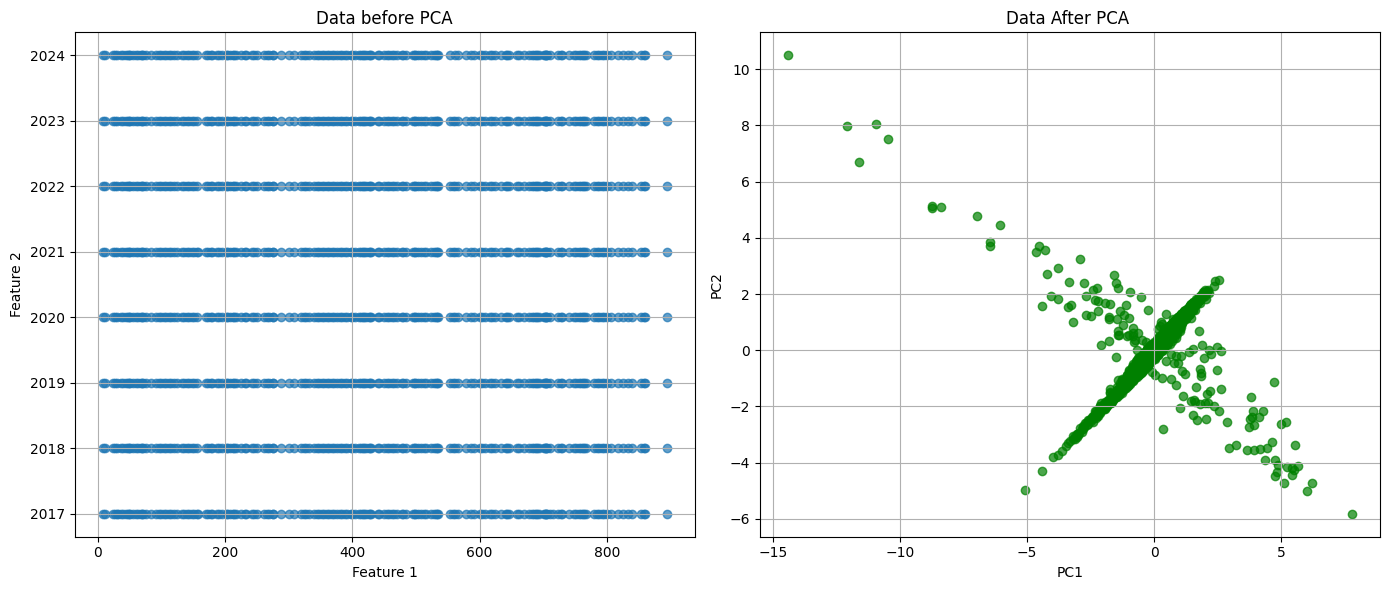

In [17]:
plt.figure(figsize=(14, 6))
# Step 8: Visualize Before and After PCA
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title('Data before PCA')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

# Plot original data (first two features for simplicity)
plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.7, c='g')
plt.title('Data After PCA ')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot reduced data after PCA
